
# 🏞️ Random Forest Regressor (Hiperparàmetres)

Podríem pensar que a Random Forest Regressor existeix un RandomForestRegressorCV, però al fet de que sigui un model no paramètric , molt més complex i amb molts més hiperpaàmetres no existeix la classe RandomForestRegressorCV

---

## 🎯 Objectius
- Veure estratègies per buscar/optimitzar els hiperparàmetres d'un Random Forest Regressor


##  🏠 Boston Housing

Volem predir la variable MEDV. valor mijtà de les vivendes.

En el conjunt de dades tenim:
- **CRIM**: taxa de delinqüència per càpita per ciutat.
- **ZN**: proporció de sòl residencial dividit per a segments de més de 25.000 peus quadrats.
- **INDUS**: proporció de superfície comercial no minorista per ciutat.
- **CHAS**: variable binària sobre el riu Charles (= 1 si la zona limita amb el riu; 0 en cas contrari).
- **NOX**: concentració d'òxids nítrics (parts de 10 milions).
- **RM**: nombre mitjà d'habitacions per habitatge.
- **EDAT**: proporció d'habitatges ocupats construïts abans del 1940.
- **DIS**: distància ponderada a cinc centres de treball a la ciutat de Boston.
- **RAD**: índex daccessibilitat a les autopistes radials.
- **TAX**: impost sobre béns immobles de valor íntegre per cada 10.000 dólars
- **PTRATIO**: ràtio alumnes-professor per ciutat.
- **LSTAT**: % de la població considerat de classe baixa.
- **MEDV** (variable a predir): valor mitjà dels habitatges en milers de $.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

# Load the Boston Housing dataset
boston = fetch_openml(name='boston')

boston
df = boston['data']
df['MEDV'] = boston['target']

# Dividim el conjunt de dades train/test
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns="MEDV"),
                                        df['MEDV'],
                                        test_size = 0.25,
                                        random_state = 54
                                    )

print(df.shape)

(506, 14)


## 🧮 Hiperparàmtre `n_estimator`

Per defecte el paràmetre `n_estimator=10` volem veure quin efecte té l'ús d'aquest hiperparàmetre en el resultat final.

Per això crearem 30 models donant a n_estimator el valors de [1,5,10,15,..150]

Valor óptimo de n_estimators: 145


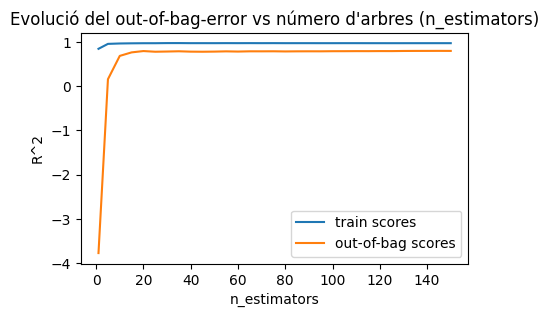

In [5]:
# Validació utilitzant el Out-of-Bag error
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

train_scores = []
oob_scores   = []
#r2_scores    = []

# Valors avaluats
estimator_range = [1] + list(range(5, 155, 5))

# Bucle per entrenar un model amb cada valor de n_estimators i extreure l'error d'entrenament.
for n_estimators in estimator_range:
    m_rfr = RandomForestRegressor(
                n_estimators = n_estimators,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = 1,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 54
             )
    m_rfr.fit(X_train, y_train)
    train_scores.append(m_rfr.score(X_train, y_train))
    oob_scores.append(m_rfr.oob_score_)

    #y_pred = m_rfr.predict(X=X_test)
    #r2_scores.append(r2_score(y_true=y_test, y_pred=y_pred))

# Gràfic amb l'evolució dels errors
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(estimator_range, train_scores, label="train scores")
ax.plot(estimator_range, oob_scores, label="out-of-bag scores")
#ax.plot(estimator_range, r2_scores, label="r2 scores")
ax.set_ylabel("R^2")
ax.set_xlabel("n_estimators")
ax.set_title("Evolució del out-of-bag-error vs número d'arbres (n_estimators)")
plt.legend();
print(f"Valor óptimo de n_estimators: {estimator_range[np.argmax(oob_scores)]}")

En el gràfic anterior veiem que el valor òptim de `n_estimators` és aquell que:
- L'**OOB score** (validació interna) s’estabilitza, és a dir, deixa de millorar significativament.
- La **diferència** entre **train_score** i **oob_score** és petita i constant.
- Afegir més arbres **no millora el rendiment**, només augmenta el cost computacional.

Estudiant `oob_score` agafem el valor de `n_estimators` quan el valor `oob_score` s'estabilitza i que la millora és inferior a un cert llindar prefixat i petit (0.001)

In [7]:
# Convertim a array per treballar més fàcilment
import numpy as np
oob_scores = np.array(oob_scores)

# Diferència entre passos consecutius
diff = np.diff(oob_scores)

# Quan la millora és inferior a un llindar petit
threshold = 0.001  # (0.1% de millora)
optimal_idx = np.where(diff < threshold)[0][0] + 1
optimal_estimators = estimator_range[optimal_idx]
print(f"n_estimators òptim ≈ {optimal_estimators}")


n_estimators òptim ≈ 25


Estudiant el `oob_score` i `train_score` agafarem `n_estimators` quan s'estabilitza `oob_score`en un cert llindar (0.001) i quan la diferència entre aquest i el `train_score` superi una altre llindar prefixat i petit (0.002)

In [8]:
import numpy as np

# Convertim a array per a càlculs vectorials
train_scores = np.array(train_scores)
oob_scores   = np.array(oob_scores)

# Diferència entre passos consecutius de l'OOB score
oob_diff = np.diff(oob_scores)

# Diferència entre train i oob per a cada n_estimators
gap = train_scores - oob_scores
gap_diff = np.diff(gap)

# Llindars de tolerància
threshold_oob = 0.001   # millora mínima acceptable de l'OOB
threshold_gap = 0.002   # variació mínima acceptable del gap

# Criteri: el punt on l'OOB s'estabilitza i el gap deixa de variar
for i in range(1, len(estimator_range)-1):
    if abs(oob_diff[i-1]) < threshold_oob and abs(gap_diff[i-1]) < threshold_gap:
        optimal_estimators = estimator_range[i]
        break

print(f"n_estimators òptim ≈ {optimal_estimators}")


n_estimators òptim ≈ 70


## 🧮 Hiperparàmtre `max_features`

Aques paràemtre és un del més important en un Random Forest, perquè és el que permet controlar quan es decorrrelacionen els arbre entre si.


Valor òptim de max_features: 8


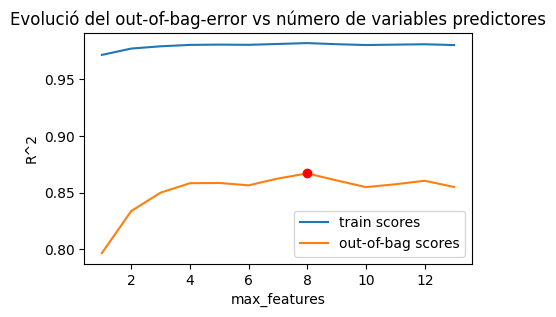

In [13]:
train_scores = []
oob_scores   = []

# Valores evaluados
max_features_range = range(1, X_train.shape[1] + 1, 1)

# Bucle para entrenar un modelo con cada valor de max_features y extraer su error
# de entrenamiento y de Out-of-Bag.
for max_features in max_features_range:
    m_rfr = RandomForestRegressor(
                n_estimators = 70, #amb el càlcul anterior hem vist que seria un valor proper a l'òptim.
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = max_features,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 54
             )
    m_rfr.fit(X_train, y_train)
    train_scores.append(m_rfr.score(X_train, y_train))
    oob_scores.append(m_rfr.oob_score_)

# Gràfic amb l'evolució dels errors
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(max_features_range, train_scores, label="train scores")
ax.plot(max_features_range, oob_scores, label="out-of-bag scores")
ax.plot(max_features_range[np.argmax(oob_scores)], max(oob_scores),
        marker='o', color = "red")
ax.set_ylabel("R^2")
ax.set_xlabel("max_features")
ax.set_title("Evolució del out-of-bag-error vs número de variables predictores")
plt.legend();
print(f"Valor òptim de max_features: {max_features_range[np.argmax(oob_scores)]}")


Encara que l'anàlisi individual dels hiperparèmtres és útil per interpretar l'impacte en el model i identificar els rangs més òptims no s'ha de fer de forma seqüencial perquè cada hiperparàmetres interaccions amb els demés.Per això podem utilitzar `GridSearchCV` per buscar-los tots de cop aplicant una validació creauada automàtica.
Això et permet trobar de manera sistemàtica el millor Random Forest Regressor possible

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import time

# Model base
m_rfr = RandomForestRegressor(random_state=42, n_jobs=-1)

estimator_range = [1] + list(range(5, 155, 5))  # 1,5,10,..150

max_features_range = list(range(1, X_train.shape[1] + 1, 1))

# Definim la graella d'hiperparàmetres a provar
param_grid = {
    'n_estimators': estimator_range,
    'max_depth': [None, 10, 20],
    'max_features': max_features_range
}

# Configurem la validació creuada
grid = GridSearchCV(
    estimator=m_rfr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Entrenem
start = time.time()
grid.fit(X_train, y_train)
stop = time.time()
print(f"Temps d'entrenament: {stop - start} segons")

# Resultats
print("Millors paràmetres:", grid.best_params_)
print("Millor score CV:", grid.best_score_)
print("Millor model:", grid.best_estimator_)


Temps d'entrenament: 1295.0348870754242 segons
Millors paràmetres: {'max_depth': None, 'max_features': 5, 'n_estimators': 75}
Millor score CV: 0.8413323054091315
Millor model: RandomForestRegressor(max_features=5, n_estimators=75, n_jobs=-1,
                      random_state=42)


In [20]:
# Avaluem el millor model trobat
# ==============================================================================
m_rfr_best = grid.best_estimator_
y_pred_m_best = m_rfr_best.predict(X=X_test)

rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred_m_best)
print(f"El error (rmse) de test es: {rmse}")

r2= r2_score(y_true=y_test, y_pred=y_pred_m_best)
print(f"El error (r2) de test es: {r2}")

El error (rmse) de test es: 2.358888616680756
El error (r2) de test es: 0.9293984967943278


`GridSearchCV` pot ter molt lent quan tenim molts hiperparàemtres a buscar. Podem utilitzar una alternativa més eficient `RandomizedSearchCV` Aquesta classe prova combinacions aleatòries fent la cerca més ràpida.

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import time

# Model base
m_rfr = RandomForestRegressor(random_state=42, n_jobs=-1)

estimator_range = [1] + list(range(5, 155, 5))  # 1,5,10,..150

max_features_range = list(range(1, X_train.shape[1] + 1, 1))

# Definim la graella d'hiperparàmetres a provar
param_grid = {
    'n_estimators': estimator_range,
    'max_depth': [None, 10, 20],
    'max_features': max_features_range
}

# Configurem la validació creuada
randomCV = RandomizedSearchCV (
    estimator=m_rfr,
    param_distributions=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Entrenem
start = time.time()
randomCV.fit(X_train, y_train)
stop = time.time()
print(f"Temps d'entrenament: {stop - start} segons")

# Resultats
print("Millors paràmetres:", randomCV.best_params_)
print("Millor score CV:", randomCV.best_score_)
print("Millor model:", randomCV.best_estimator_)


# Avaluem el millor model trobat
# ==============================================================================
m_rfr_best = randomCV.best_estimator_
y_pred_m_best = m_rfr_best.predict(X=X_test)

rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred_m_best)
print(f"El error (rmse) de test es: {rmse}")

r2= r2_score(y_true=y_test, y_pred=y_pred_m_best)
print(f"El error (r2) de test es: {r2}")

Temps d'entrenament: 13.323781251907349 segons
Millors paràmetres: {'n_estimators': 75, 'max_features': 5, 'max_depth': None}
Millor score CV: 0.8413323054091315
Millor model: RandomForestRegressor(max_features=5, n_estimators=75, n_jobs=-1,
                      random_state=42)
El error (rmse) de test es: 2.3088408608509376
El error (r2) de test es: 0.9323625730001939
